# **Robot Operating System**

# ROS1 和 ROS2
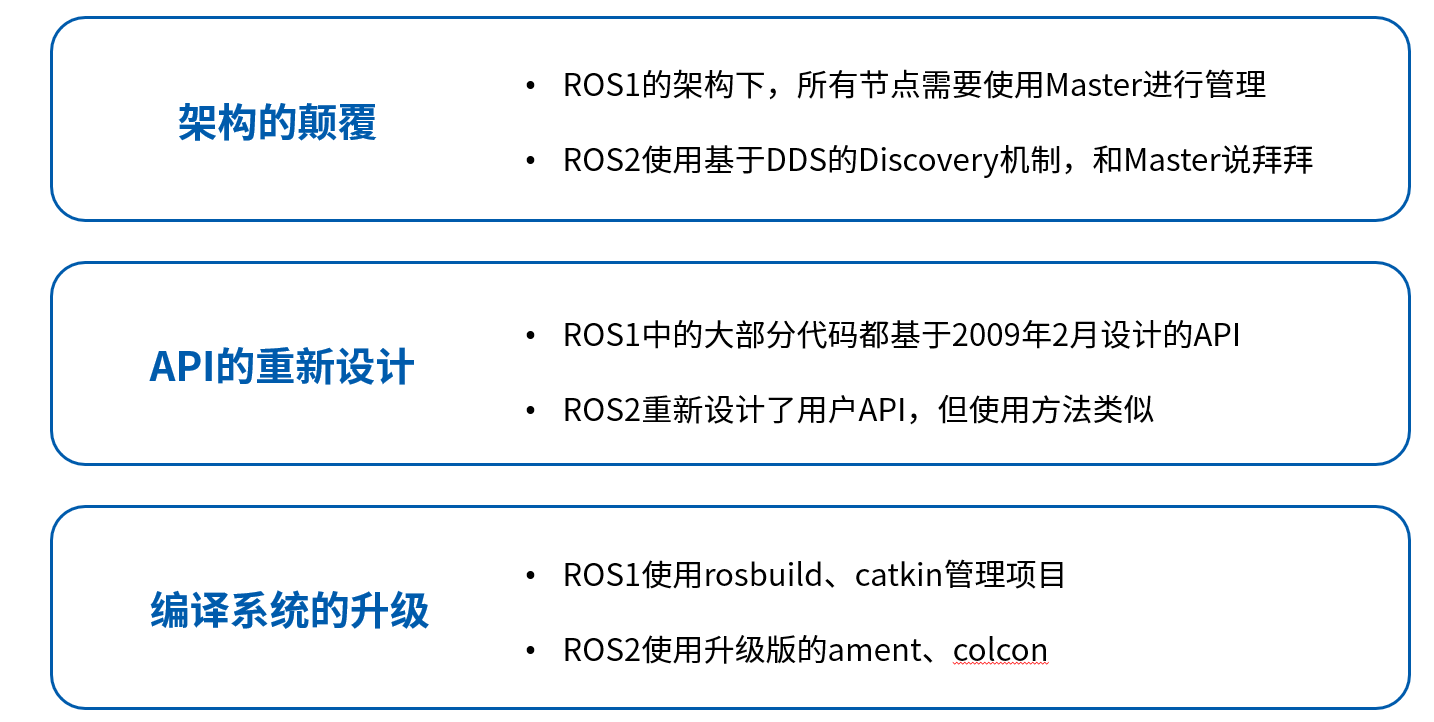
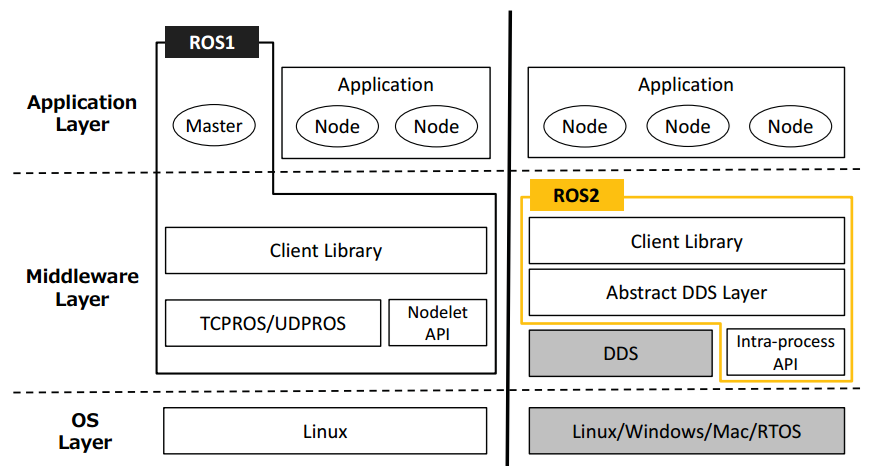

- 在ROS1中，应用层里Master这个节点管理器的角色至关重要，所有节点都得听它指挥，有且只有一个。
ROS2把这个最不稳定的角色请走了，节点可以通过另外一套discovery——自发现机制，找到彼此，从而建立稳定的通信连接。

- 中间层是ROS封装好的标准通信接口。

- 在ROS1中，ROS通信依赖底层的TCP和UDP协议，而在ROS2中，通信协议更换成了更加复杂但也更加完善的DDS系统。
如果是在进程内需要进行大量数据的通信，ROS1和ROS2都提供了基于共享内存的通信方法，只不过名字不太一样而已。

- 最下边是系统层，也就是可以将ROS安装在哪些操作系统上，ROS1主要安装在Linux上，ROS2的可选项就很多了，Linux、windows、MacOS、RTOS都可以。

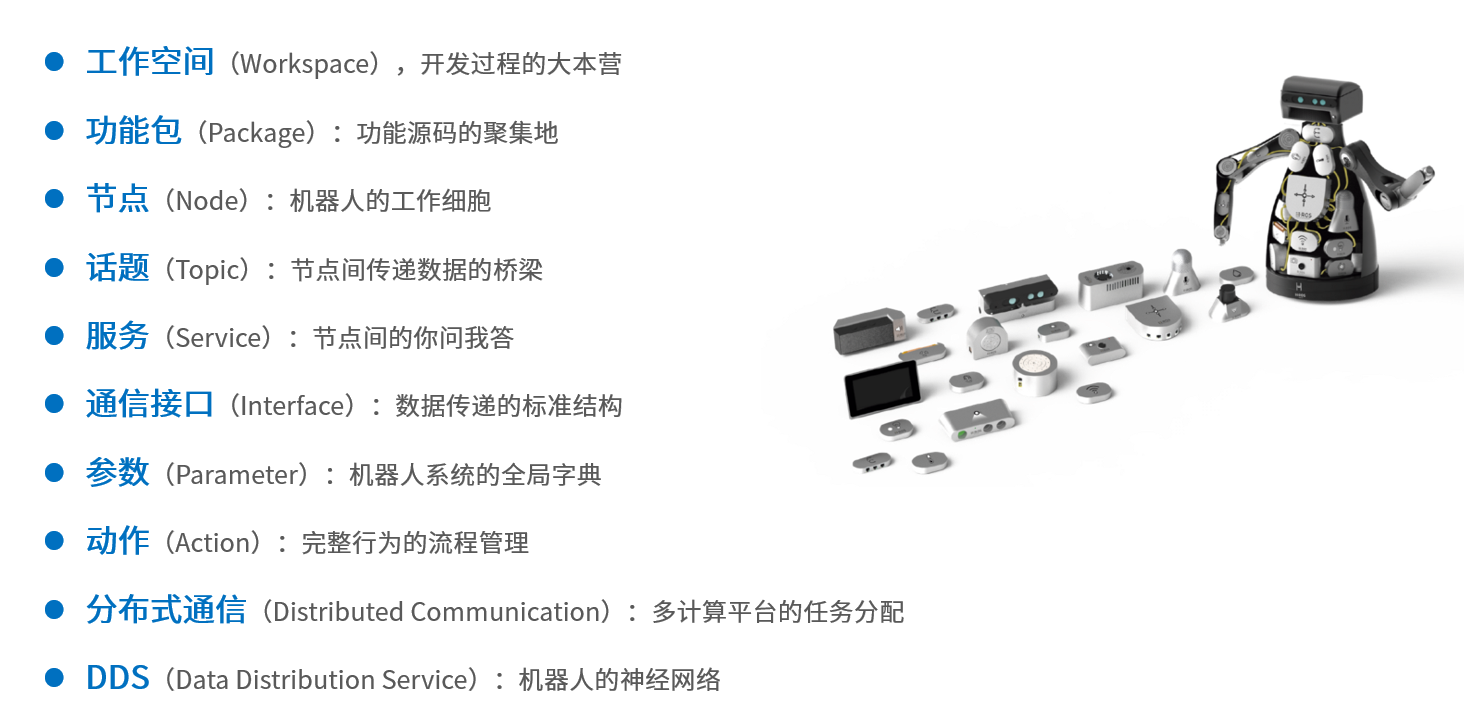

总结而言就是：  
节点干掉了Master  
通信换成了DDS  
核心概念没变化  
编程难度有上升  

# Ubuntu 与 ROS2安装


# 命令行操作
**Terminal，终端**  
启动终端的方式有很多种：  
- powershell中输入wsl
- 命令行中切换到Ubuntu，或Ctil+Shift+4
- vscode终端

## cd
cd <目录路径>  
改变工作目录。若没有指定“目录路径”，则回到用户的主目录
## pwd
显示出当前工作目录的绝对路径
## mkdir
mkdir [选项] <目录名称>  
创建一个目录/文件夹
## ls
ls [选项] [目录名称…]  
列出目录/文件夹中的文件列表
## gedit
gedit <文件名称>  
打开gedit编辑器编辑文件，若没有此文件则会新建
## mv
mv [选项] <源文件或目录> <目地文件或目录>  
为文件或目录改名或将文件由一个目录移入另一个目录中
## cp
cp [选项] <源文件名称或目录名称> <目的文件名称或目录名称>  
把一个文件或目录拷贝到另一文件或目录中，或者把多个源文件复制到目标目录中
## rm
rm [选项] <文件名称或目录名称…>  
删除一个目录中的一个或多个文件或目录，它也可以将某个目录及其下的所有文件及子目录均删除。对于链接文件，只是删除了链接，原有文件均保持不变
## sudo
sudo [选项] [指令]  
以系统管理员权限来执行指令

# ROS2命令行
ROS2命令行的操作机制与Linux相同，不过所有操作都集成在一个ros2的总命令中，后边第一个参数表示不同的操作目的，  
比如node表示对节点的操作，topic表示对话题的操作，具体操作干什么，还可以在后边继续跟一系列参数内容。  

## ros2 run 运行节点
第一个参数表示功能包的名称，第二个参数表示功能包内节点的名称  

对于运行海龟仿真节点和键盘控制节点的命令：  
```
$ ros2 run turtlesim turtlesim_node  
$ ros2 run turtlesim turtle_teleop_key
```

## ros2 node list 查看节点
```
$ ros2 node list 
```
对某一个节点感兴趣，加上一个info子命令，就可以知道它的详细信息啦
```
ros2 node info /turtlesim
```

## ros2 topic list 查看话题
```
$ ros2 topic list
```
还想看到某一个话题中的消息数据，加上echo子命令
```
$ ros2 topic echo /turtle1/pose
```

## 发布话题
```
$ ros2 topic pub --rate 1 /turtle1/cmd_vel geometry_msgs/msg/Twist "{linear: {x: 2.0, y: 0.0, 
z: 0.0}, angular: {x: 0.0, y: 0.0, z: 1.8}}" 
```

## 发布服务请求
```
$ ros2 service call /spawn turtlesim/srv/Spawn "{x: 2, y: 2, theta: 0.2, name: ''}"
```

## 发送动作目标
```
$ ros2 action send_goal /turtle1/rotate_absolute turtlesim/action/RotateAbsolute "theta: 3"
```

## 数据录制与播放
```
#数据录制 
$ ros2 bag record /turtle1/cmd_vel 
#数据播放 (注意路径和文件名)
$ ros2 bag play rosbag2_2024_07_06-21_21_23/ rosbag2_2024_07_06-21_21_23_0.mcap
```

# 工作空间

## 定义与结果

我们想要编写程序之前，都会在开发环境的工具栏中，点击一个“创建新工程”的选项，此时就产生一个文件夹，后续所有工作产生的文件，都会放置在这个文件夹中，这个文件夹以及里边的内容，就叫做 **工程** 。

在ROS机器人开发中，我们针对机器人某些功能进行代码开始时，各种编写的代码、参数、脚本等文件，也需要放置在某一个文件夹里进行管理，这个文件夹在ROS系统中就叫做 **工作空间** 。

所以工作空间是一个存放项目开发相关文件的文件夹，也是开发过程中存放所有资料的大本营。

ROS系统中一个典型的工作空间结构如图所示，这个dev_ws就是工作空间的根目录，里边会有四个子目录，或者叫做四个子空间。

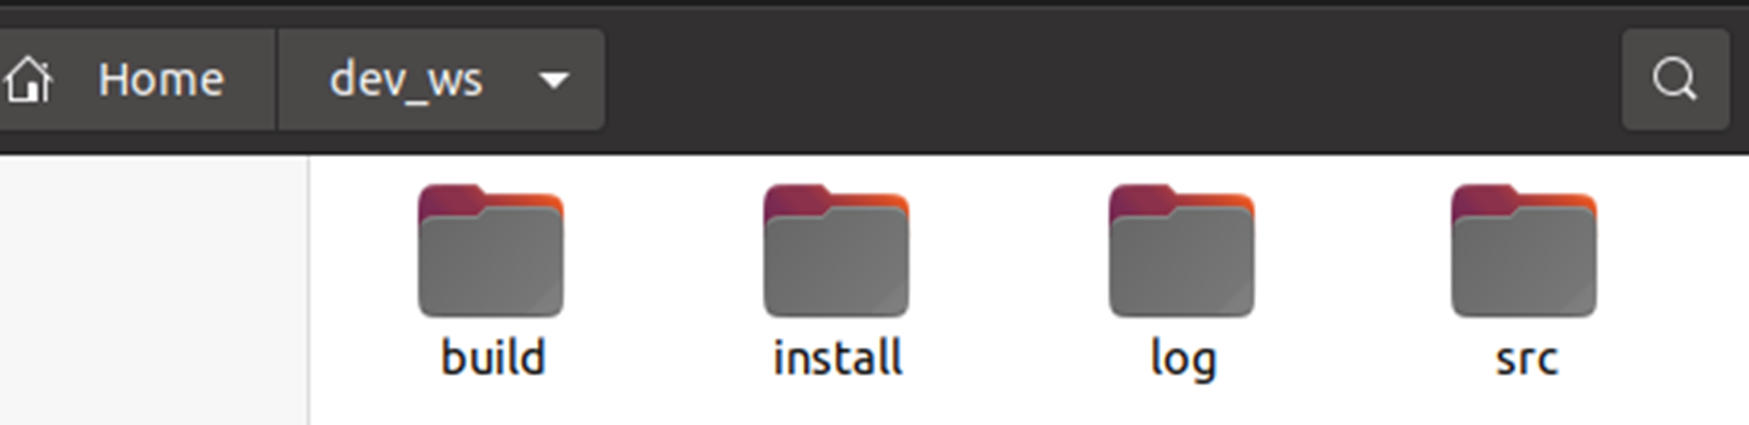

- src，代码空间，未来编写的代码、脚本，都需要人为的放置到这里；
- build，编译空间，保存编译过程中产生的中间文件；
- install，安装空间，放置编译得到的可执行文件和脚本；
- log，日志空间，编译和运行过程中，保存各种警告、错误、信息等日志

这四个空间的文件夹，我们绝大部分操作都是在src中进行的，编译成功后，就会执行install里边的结果，build和log两个文件夹用的很少。

## 创建工作空间
